# DukaStock — Notebook 4: Results Dashboard

Synthesizes the outputs of Notebooks 1–3 into publication-quality figures
for the capstone defense. This notebook does not run any new experiments —
it loads the saved results from the other three notebooks and produces a
cohesive, presentation-ready set of visuals.

### Prerequisites

Run Notebooks 1, 2, and 3 first so the following files exist:

| File | Produced by |
|---|---|
| `ml_experiments/data/fmcg_rwanda_localized.csv` | Notebook 1 |
| `ml_experiments/results/ml_benchmark_results.csv` | Notebook 2 |
| `ml_experiments/results/ner_model_comparison.csv` | Notebook 3 |
| `ml_experiments/results/ner_kappa.json` | Notebook 3 |

If any file is missing, this notebook will tell you which notebook to run
and will skip just that section rather than failing outright.


In [28]:
# Cell 1 — Imports
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
GROWTHWAVE_GREEN = "#1a6e3c"
GROWTHWAVE_ACCENT = "#25a65a"


In [29]:
# Cell 2 — Locate all input files, warn (don't crash) on anything missing
from pathlib import Path
import os

# Anchor to repo root regardless of where the kernel was launched from.
# This notebook lives at ml_experiments/notebooks/ → two levels up is the repo root.
_NB_DIR = Path(globals().get('__vsc_ipynb_file__', __file__)).resolve().parent \
          if '__file__' in dir() else Path().resolve()
# Walk up until we find a known repo marker (pyproject.toml, .git, or RUNBOOK.md)
_REPO_ROOT = _NB_DIR
for _candidate in [_NB_DIR, _NB_DIR.parent, _NB_DIR.parent.parent]:
    if any((_candidate / marker).exists() for marker in ['RUNBOOK.md', '.git', 'pyproject.toml']):
        _REPO_ROOT = _candidate
        break

# Change CWD to repo root so relative paths work everywhere in the notebook
os.chdir(_REPO_ROOT)
print(f"Repo root: {_REPO_ROOT}")

RESULTS_DIR = _REPO_ROOT / "ml_experiments" / "results"
DATA_DIR    = _REPO_ROOT / "ml_experiments" / "data"

paths = {
    "localized_data": DATA_DIR  / "fmcg_rwanda_localized.csv",
    "ml_benchmark":   RESULTS_DIR / "ml_benchmark_results.csv",
    "ner_comparison": RESULTS_DIR / "ner_model_comparison.csv",
    "ner_kappa":      RESULTS_DIR / "ner_kappa.json",
    "sus_scores":     RESULTS_DIR / "sus_scores_per_participant.csv",
    "sus_summary":    RESULTS_DIR / "sus_scores_by_channel.csv",
}

availability = {}
for name, path in paths.items():
    exists = path.exists()
    availability[name] = exists
    print(f"{'OK  ' if exists else 'MISSING'}  {name:18s} -> {path}")

if not availability["ml_benchmark"]:
    print("\n  Run Notebook 2 (ML Benchmark Experiment) to produce ml_benchmark_results.csv")
if not availability["ner_comparison"]:
    print("  Run Notebook 3 (XLM-R Commerce NER) to produce ner_model_comparison.csv")
if not availability["sus_summary"]:
    print("  Run ml_experiments/scripts/score_sus.py --output-dir ml_experiments/results "
          "on your collected SUS responses to produce sus_scores_by_channel.csv "
          "(see docs/SUS_QUESTIONNAIRE.md)")


Repo root: /Users/abizera/Documents/ALU/Capstone/dukastock 2
OK    localized_data     -> /Users/abizera/Documents/ALU/Capstone/dukastock 2/ml_experiments/data/fmcg_rwanda_localized.csv
OK    ml_benchmark       -> /Users/abizera/Documents/ALU/Capstone/dukastock 2/ml_experiments/results/ml_benchmark_results.csv
OK    ner_comparison     -> /Users/abizera/Documents/ALU/Capstone/dukastock 2/ml_experiments/results/ner_model_comparison.csv
OK    ner_kappa          -> /Users/abizera/Documents/ALU/Capstone/dukastock 2/ml_experiments/results/ner_kappa.json
MISSING  sus_scores         -> /Users/abizera/Documents/ALU/Capstone/dukastock 2/ml_experiments/results/sus_scores_per_participant.csv
MISSING  sus_summary        -> /Users/abizera/Documents/ALU/Capstone/dukastock 2/ml_experiments/results/sus_scores_by_channel.csv
  Run ml_experiments/scripts/score_sus.py --output-dir ml_experiments/results on your collected SUS responses to produce sus_scores_by_channel.csv (see docs/SUS_QUESTIONNAIRE.md)


## 1. Headline figure: the threshold curve

This is the single figure that most directly answers the primary research
question, formatted for the thesis defense slide deck.


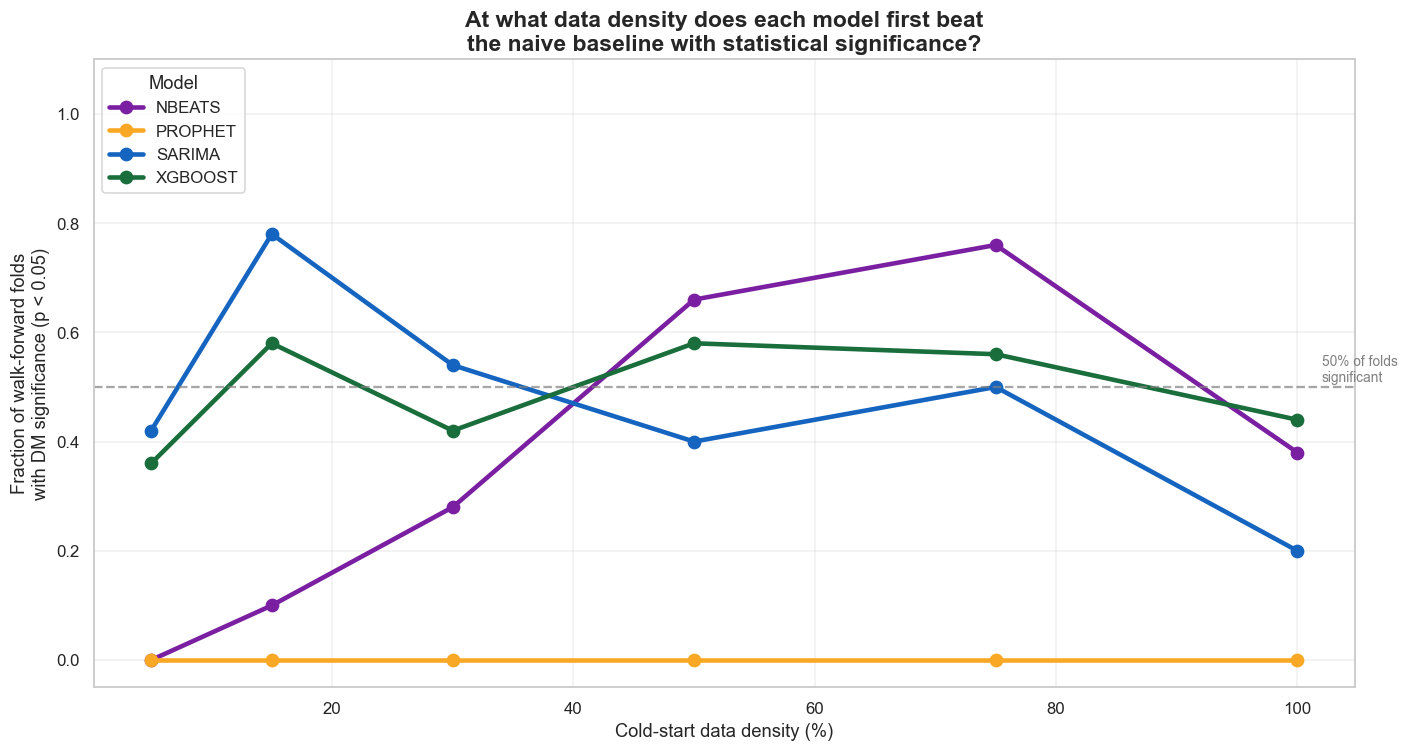

Saved to /Users/abizera/Documents/ALU/Capstone/dukastock 2/ml_experiments/results/figure_threshold_curve.png


In [30]:
# Cell 3 — Figure 1: Headline threshold curve (defense-ready formatting)
if availability["ml_benchmark"]:
    benchmark_df = pd.read_csv(paths["ml_benchmark"])
    dm_df = benchmark_df.dropna(subset=["fraction_folds_significant"]) if "fraction_folds_significant" in benchmark_df.columns else pd.DataFrame()

    if len(dm_df) > 0:
        fig, ax = plt.subplots(figsize=(13, 7))
        model_colors = {"sarima": "#1565c0", "prophet": "#f9a825", "xgboost": GROWTHWAVE_GREEN, "nbeats": "#7b1fa2"}
        for model_name, group in dm_df.groupby("model"):
            avg = group.groupby("density_pct")["fraction_folds_significant"].mean().reset_index()
            ax.plot(avg["density_pct"], avg["fraction_folds_significant"], marker="o", markersize=8,
                    linewidth=3, label=model_name.upper(), color=model_colors.get(model_name))

        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.text(102, 0.51, "50% of folds\nsignificant", fontsize=9, color="gray")
        ax.set_title("At what data density does each model first beat\nthe naive baseline with statistical significance?",
                      fontweight="bold", fontsize=15)
        ax.set_xlabel("Cold-start data density (%)", fontsize=12)
        ax.set_ylabel("Fraction of walk-forward folds\nwith DM significance (p < 0.05)", fontsize=12)
        ax.set_ylim(-0.05, 1.1)
        ax.legend(title="Model", fontsize=11, title_fontsize=12, loc="upper left")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "figure_threshold_curve.png", dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved to {RESULTS_DIR / 'figure_threshold_curve.png'}")
    else:
        print("No Diebold-Mariano columns found in the benchmark results — re-run Notebook 2.")
else:
    print("Skipped: ml_benchmark_results.csv not found. Run Notebook 2 first.")


## 2. Model leaderboard across all metrics


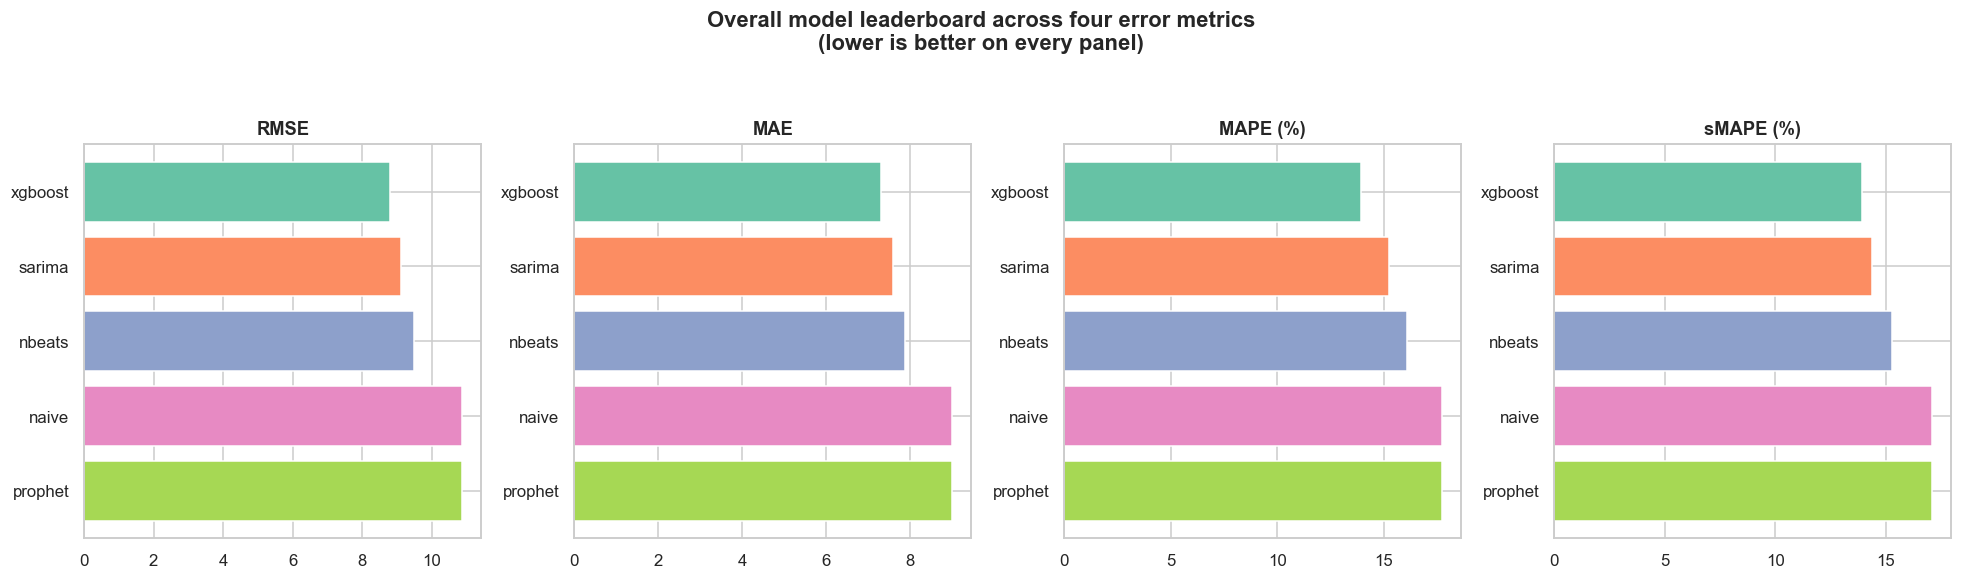


Full leaderboard table:
         mean_rmse  mean_mae  mean_mape  mean_smape
model                                              
xgboost       8.81      7.29      13.94       13.92
sarima        9.12      7.59      15.25       14.36
nbeats        9.49      7.88      16.08       15.29
naive        10.88      9.00      17.75       17.11
prophet      10.88      9.00      17.75       17.11


In [31]:
# Cell 4 — Figure 2: Multi-metric leaderboard
if availability["ml_benchmark"]:
    leaderboard = benchmark_df.groupby("model").agg(
        mean_rmse=("rmse", "mean"), mean_mae=("mae", "mean"),
        mean_mape=("mape", "mean"), mean_smape=("smape", "mean"),
    ).round(2)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    metrics = [("mean_rmse", "RMSE"), ("mean_mae", "MAE"), ("mean_mape", "MAPE (%)"), ("mean_smape", "sMAPE (%)")]
    for ax, (col, label) in zip(axes, metrics):
        sorted_lb = leaderboard.sort_values(col)
        ax.barh(sorted_lb.index, sorted_lb[col], color=sns.color_palette("Set2", len(sorted_lb)))
        ax.set_title(label, fontweight="bold")
        ax.invert_yaxis()
    plt.suptitle("Overall model leaderboard across four error metrics\n(lower is better on every panel)",
                 fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "figure_leaderboard.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("\nFull leaderboard table:")
    print(leaderboard.sort_values("mean_rmse"))
else:
    print("Skipped: ml_benchmark_results.csv not found.")


## 3. Per-product breakdown


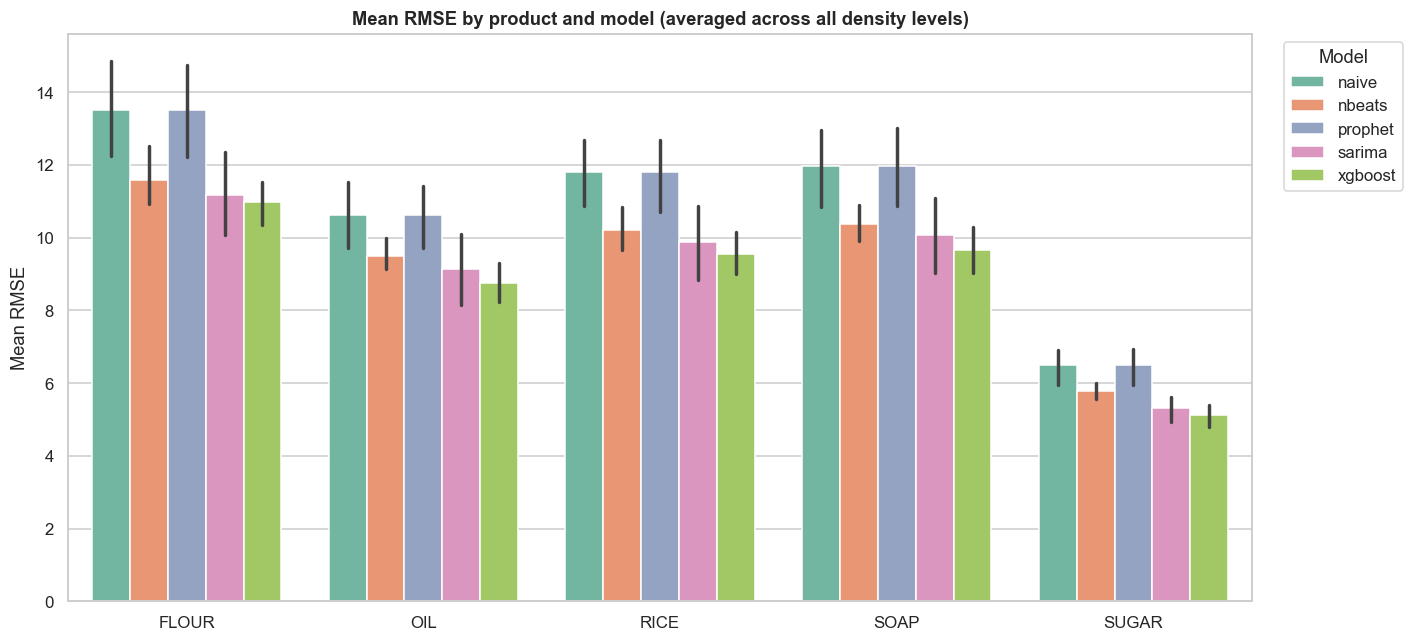

In [32]:
# Cell 5 — Figure 3: Per-product RMSE comparison, faceted
if availability["ml_benchmark"]:
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(data=benchmark_df, x="product", y="rmse", hue="model", ax=ax, palette="Set2")
    ax.set_title("Mean RMSE by product and model (averaged across all density levels)", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Mean RMSE")
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "figure_per_product_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Skipped: ml_benchmark_results.csv not found.")


## 4. NLP results: XLM-R vs. RapidFuzz


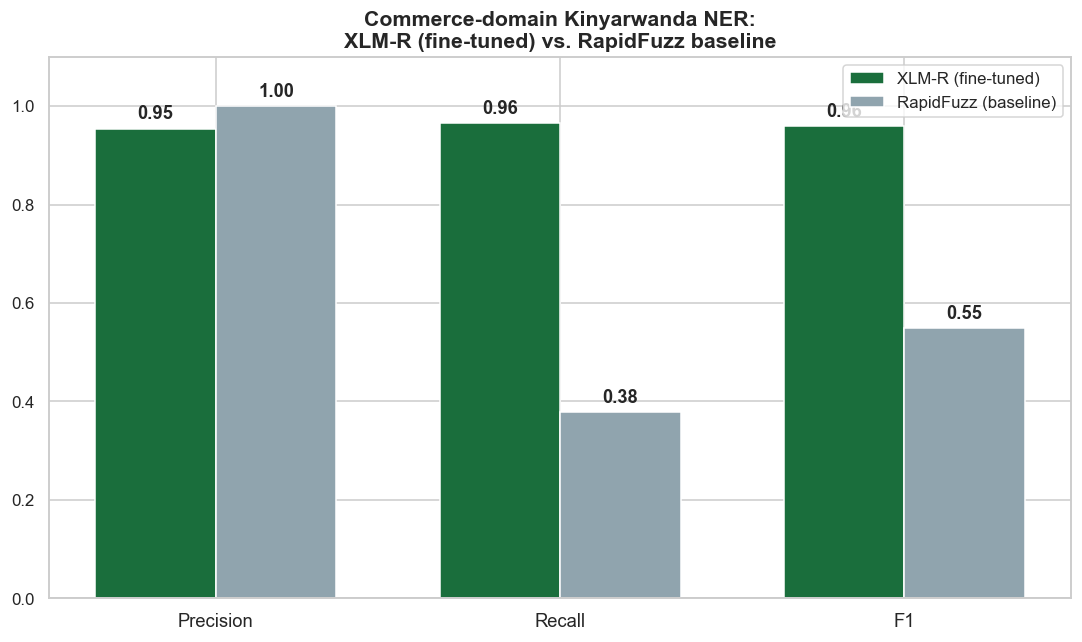


Cohen's Kappa (inter-annotator agreement): 0.951


In [33]:
# Cell 6 — Figure 4: NER model comparison (defense-ready)
if availability["ner_comparison"]:
    ner_df = pd.read_csv(paths["ner_comparison"])
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(3)
    width = 0.35
    metrics_cols = ["Precision", "Recall", "F1"]

    xlmr_row = ner_df[ner_df["Model"].str.contains("XLM-R")].iloc[0]
    rf_row = ner_df[ner_df["Model"].str.contains("RapidFuzz")].iloc[0]

    ax.bar(x - width/2, [xlmr_row[m] for m in metrics_cols], width, label="XLM-R (fine-tuned)", color=GROWTHWAVE_GREEN)
    ax.bar(x + width/2, [rf_row[m] for m in metrics_cols], width, label="RapidFuzz (baseline)", color="#90a4ae")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_cols, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_title("Commerce-domain Kinyarwanda NER:\nXLM-R (fine-tuned) vs. RapidFuzz baseline", fontweight="bold", fontsize=14)
    ax.legend(fontsize=11)
    for i, m in enumerate(metrics_cols):
        ax.text(i - width/2, xlmr_row[m] + 0.02, f"{xlmr_row[m]:.2f}", ha="center", fontweight="bold")
        ax.text(i + width/2, rf_row[m] + 0.02, f"{rf_row[m]:.2f}", ha="center", fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "figure_ner_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

    if availability["ner_kappa"]:
        with open(paths["ner_kappa"]) as f:
            kappa_data = json.load(f)
        print(f"\nCohen's Kappa (inter-annotator agreement): {kappa_data['cohens_kappa']:.3f}")
        if kappa_data.get("using_synthetic_data"):
            print("*** WARNING: this run used SYNTHETIC placeholder annotations. ***")
            print("*** Re-run Notebook 3 with real annotated data before citing these numbers. ***")
else:
    print("Skipped: ner_model_comparison.csv not found. Run Notebook 3 first.")


## 5. Usability results: System Usability Scale (tertiary research question)

Addresses: "What usability patterns emerge from System Usability Scale
scores when Duka operators interact with the WhatsApp and USSD prototype
channels?" See `docs/SUS_QUESTIONNAIRE.md` for the questionnaire, the
administration protocol, and `ml_experiments/scripts/score_sus.py` for how
raw 1-5 responses become the 0-100 scores visualized below.


In [34]:
# Cell 6b — Figure 4b: SUS scores by channel, with the published 68-point benchmark line
if availability["sus_summary"]:
    sus_summary = pd.read_csv(paths["sus_summary"])
    sus_per_participant = pd.read_csv(paths["sus_scores"]) if availability["sus_scores"] else None

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    axes[0].bar(sus_summary["channel"], sus_summary["mean_sus_score"], color=GROWTHWAVE_GREEN, alpha=0.85)
    axes[0].axhline(68, color="gray", linestyle="--", linewidth=1.5, label="Published benchmark (68)")
    axes[0].set_ylim(0, 100)
    axes[0].set_ylabel("Mean SUS score")
    axes[0].set_title("Mean SUS score by channel", fontweight="bold")
    axes[0].legend()
    for i, row in sus_summary.iterrows():
        axes[0].text(i, row["mean_sus_score"] + 2, f"{row['mean_sus_score']:.1f}\n(n={row['n_participants']})",
                      ha="center", fontweight="bold", fontsize=9)

    if sus_per_participant is not None:
        sns.stripplot(data=sus_per_participant, x="channel", y="sus_score", ax=axes[1],
                       size=10, color=GROWTHWAVE_ACCENT, jitter=True)
        axes[1].axhline(68, color="gray", linestyle="--", linewidth=1.5)
        axes[1].set_ylim(0, 100)
        axes[1].set_title("Individual participant SUS scores by channel", fontweight="bold")
        axes[1].set_ylabel("SUS score")

    plt.suptitle("DukaStock Usability: System Usability Scale Results", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "figure_sus_results.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(sus_summary.to_string(index=False))
    print()
    print("Published benchmark: mean SUS score across hundreds of studies is 68/100.")
    print("Scores above 68 indicate above-average perceived usability for this sample.")

    if availability["sus_scores"] and sus_per_participant is not None and len(sus_per_participant) < 8:
        print()
        print(f"NOTE: n={len(sus_per_participant)} total responses. Treat as formative/exploratory "
              "feedback (consistent with this project's minimum-3-participant demonstration scope), "
              "not as a statistically generalizable usability claim.")
else:
    print("Skipped: sus_scores_by_channel.csv not found.")
    print("Run ml_experiments/scripts/score_sus.py on your collected SUS responses first —")
    print("see docs/SUS_QUESTIONNAIRE.md for the questionnaire and administration protocol.")


Skipped: sus_scores_by_channel.csv not found.
Run ml_experiments/scripts/score_sus.py on your collected SUS responses first —
see docs/SUS_QUESTIONNAIRE.md for the questionnaire and administration protocol.


## 6. Project summary infographic

A single combined figure summarizing the three core findings, suitable as
the final slide of a thesis defense.


/var/folders/0y/x90jhr_15jl2z20gltt_p_dw0000gp/T/ipykernel_83109/2039814723.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


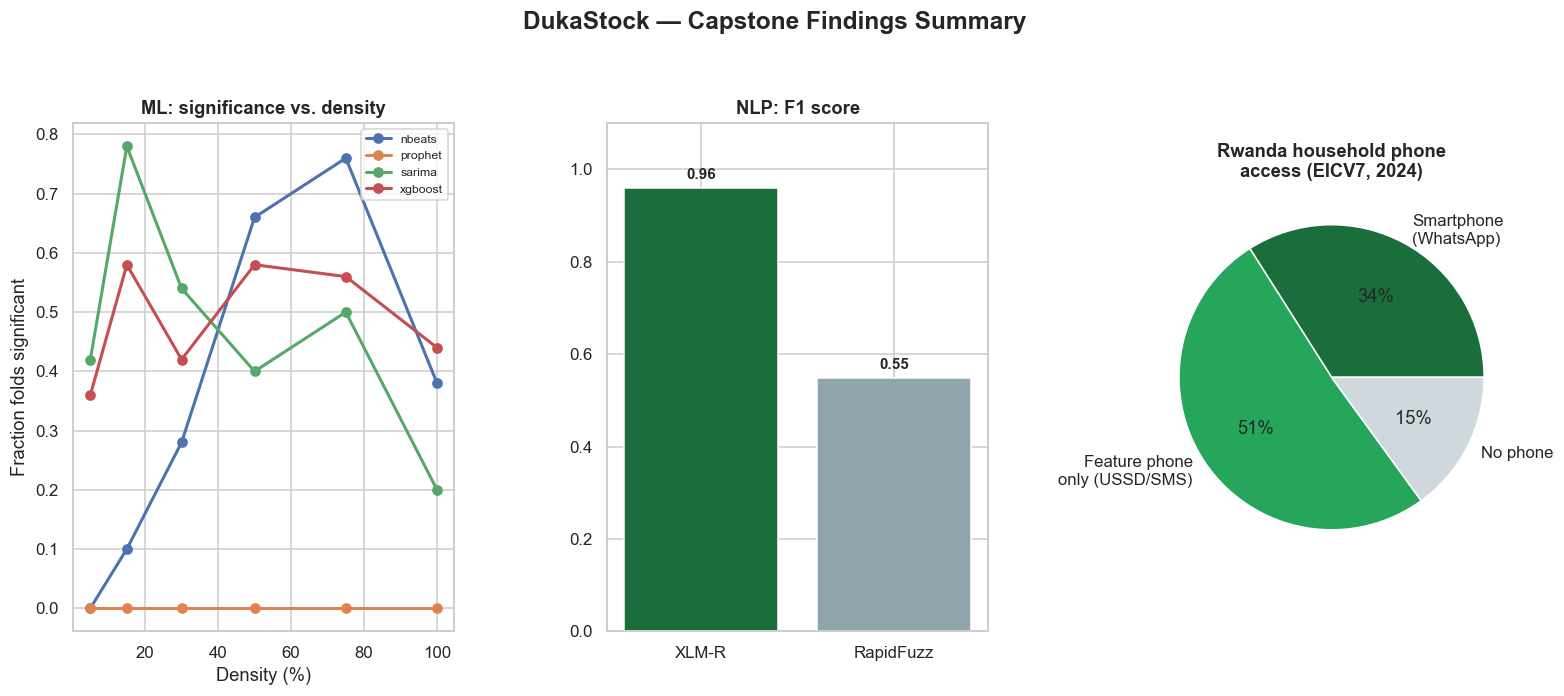

Saved: figure_summary_dashboard.png (3 panels — SUS panel excluded: no data yet)


In [35]:
# Cell 7 — Figure 5: Combined summary dashboard (dynamic panels)
# SUS panel is only included when sus_summary data is available;
# otherwise the figure shrinks to 3 panels to avoid empty placeholders.

include_sus = availability["sus_summary"]
n_panels = 4 if include_sus else 3
fig_width = 22 if include_sus else 17

fig = plt.figure(figsize=(fig_width, 6))
gs = gridspec.GridSpec(1, n_panels, figure=fig, wspace=0.4)

# ── Panel 1: threshold curve ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
if availability["ml_benchmark"] and len(dm_df) > 0:
    for model_name, group in dm_df.groupby("model"):
        avg = group.groupby("density_pct")["fraction_folds_significant"].mean().reset_index()
        ax1.plot(avg["density_pct"], avg["fraction_folds_significant"],
                 marker="o", linewidth=2, label=model_name)
    ax1.set_title("ML: significance vs. density", fontweight="bold")
    ax1.set_xlabel("Density (%)")
    ax1.set_ylabel("Fraction folds significant")
    ax1.legend(fontsize=8)
else:
    ax1.text(0.5, 0.5, "Run Notebook 2", ha="center", va="center", color="gray")
    ax1.set_title("ML: significance vs. density", fontweight="bold")

# ── Panel 2: NER comparison ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
if availability["ner_comparison"]:
    ax2.bar(["XLM-R", "RapidFuzz"], [xlmr_row["F1"], rf_row["F1"]],
            color=[GROWTHWAVE_GREEN, "#90a4ae"])
    ax2.set_title("NLP: F1 score", fontweight="bold")
    ax2.set_ylim(0, 1.1)
    for j, (model, val) in enumerate(zip(["XLM-R", "RapidFuzz"],
                                          [xlmr_row["F1"], rf_row["F1"]])):
        ax2.text(j, val + 0.02, f"{val:.2f}", ha="center", fontweight="bold", fontsize=10)
else:
    ax2.text(0.5, 0.5, "Run Notebook 3", ha="center", va="center", color="gray")
    ax2.set_title("NLP: F1 score", fontweight="bold")

# ── Panel 3: SUS usability (only if data exists) ──────────────────────
if include_sus:
    ax3 = fig.add_subplot(gs[2])
    ax3.bar(sus_summary["channel"], sus_summary["mean_sus_score"], color=GROWTHWAVE_GREEN)
    ax3.axhline(68, color="gray", linestyle="--", linewidth=1, label="SUS benchmark (68)")
    ax3.set_ylim(0, 100)
    ax3.set_title("Usability: mean SUS score", fontweight="bold")
    ax3.legend(fontsize=8)
    pie_panel = gs[3]
else:
    pie_panel = gs[2]  # pie takes the 3rd slot when SUS is absent

# ── Panel 4 (or 3): Rwanda phone access pie ───────────────────────────
ax_pie = fig.add_subplot(pie_panel)
channel_data = pd.Series({
    "Smartphone\n(WhatsApp)": 34,
    "Feature phone\nonly (USSD/SMS)": 85 - 34,
    "No phone": 100 - 85,
})
ax_pie.pie(channel_data, labels=channel_data.index, autopct="%1.0f%%",
           colors=["#1a6e3c", "#25a65a", "#cfd8dc"])
ax_pie.set_title("Rwanda household phone\naccess (EICV7, 2024)", fontweight="bold")

plt.suptitle("DukaStock — Capstone Findings Summary", fontweight="bold", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figure_summary_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: figure_summary_dashboard.png ({n_panels} panels"
      + ("" if include_sus else " — SUS panel excluded: no data yet") + ")")


## 7. Export all figures for the thesis document

All figures in this notebook are saved as standalone PNGs in
`ml_experiments/results/` at publication resolution (200 DPI), ready to
embed directly into the thesis Word document or defense slides.


In [36]:
# Cell 8 — List all exported figures
exported_figures = sorted(RESULTS_DIR.glob("figure_*.png"))
print(f"Exported {len(exported_figures)} figures to {RESULTS_DIR}:")
for f in exported_figures:
    print(f"  - {f.name}")


Exported 5 figures to /Users/abizera/Documents/ALU/Capstone/dukastock 2/ml_experiments/results:
  - figure_leaderboard.png
  - figure_ner_comparison.png
  - figure_per_product_rmse.png
  - figure_summary_dashboard.png
  - figure_threshold_curve.png


## Summary

This dashboard notebook synthesized:

1. The **threshold curve** — the direct visual answer to the primary research question.
2. A **multi-metric model leaderboard** across RMSE, MAE, MAPE, and sMAPE.
3. **Per-product breakdowns** showing where model performance varies by FMCG category.
4. The **NLP comparison** between fine-tuned XLM-R and the RapidFuzz baseline — the secondary research question.
5. **SUS usability results** by channel — the tertiary research question.
6. A **combined summary infographic** suitable as a defense closing slide.

All figures are saved as standalone, publication-resolution PNGs in
`ml_experiments/results/` for direct inclusion in the written thesis.

**Reminder:** any panel above that drew from Notebook 3's NER results
carries that notebook's synthetic-data caveat forward. Check the printed
warnings in the NLP section before using those specific numbers in the
final document. Likewise, SUS results are only as real as the response
data fed into `score_sus.py` — see `docs/SUS_QUESTIONNAIRE.md`.
